# Linear regression

### From the normal equation to scikit-learn, in one sitting

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How linear regression works, how to derive and code it yourself, how to use the library version properly, and when it is the wrong tool |
| **You should already know** | Python, NumPy arrays, and what a mean is |
| **Dataset** | California Housing (20,640 districts) and Bike Sharing (17,379 hours) |
| **Runtime** | Under a minute on a laptop CPU |
| **Next** | [02-02 Gradient descent](../02-gradient-descent/) |

---

Linear regression is the first thing anybody learns and the last thing anybody
throws away. It is fast, it never surprises you, and every more complicated
method in this book gets compared against it. If a neural network cannot beat a
straight line on your data, that is worth knowing before you spend a week tuning it.

## 1. The idea

You know several numbers about a California district and you want one you do not
have, its median house value. Linear regression assumes the answer is a
**weighted sum** of the numbers you already have, plus a constant.

For a California district: take the median income, multiply it by some weight.
Take the average number of rooms, multiply it by another weight. Add them all
up, add a constant, and that is your predicted house value.

$$\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$$

The whole job is finding the weights. "Best" here means the weights that make
the total squared error as small as possible.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the repo root so `toolkit` imports no matter where the notebook sits.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

X, y = datasets.california_housing()
print(f"{X.shape[0]:,} districts, {X.shape[1]} features")
print(f"target: median house value in $100,000s, from {y.min():.2f} to {y.max():.2f}")
X.head()

20,640 districts, 8 features
target: median house value in $100,000s, from 0.15 to 5.00


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### One feature first

Before eight features at once, look at one. Median income is the strongest
single predictor of house value, which is not a surprise but is a good place to
see the line.

slope     = 0.4179
intercept = 0.4509


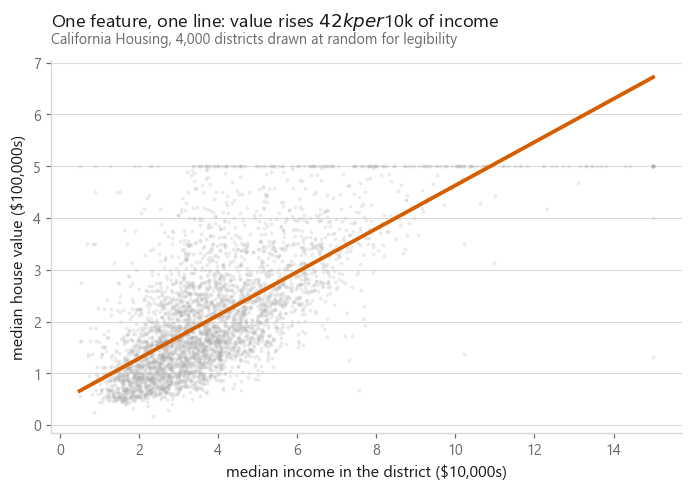

In [2]:
fig, ax = plt.subplots(figsize=(7.4, 4.4))

sample = np.random.default_rng(SEED).choice(len(X), 4000, replace=False)
ax.scatter(X.MedInc.values[sample], y.values[sample], s=6, alpha=0.25,
           c=style.NEUTRAL, linewidths=0)

# Fit a line through one feature. polyfit returns [slope, intercept].
slope, intercept = np.polyfit(X.MedInc, y, deg=1)
grid = np.linspace(X.MedInc.min(), X.MedInc.max(), 100)
ax.plot(grid, slope * grid + intercept, color=style.HIGHLIGHT, lw=2.5)

ax.set_xlabel("median income in the district ($10,000s)")
ax.set_ylabel("median house value ($100,000s)")
style.title(ax,
            f"One feature, one line: value rises ${slope * 100:.0f}k per $10k of income",
            "California Housing, 4,000 districts drawn at random for legibility")
style.save(fig, FIG / "fig-01-the-line.png")

print(f"slope     = {slope:.4f}")
print(f"intercept = {intercept:.4f}")

Two things to notice, because both come back later.

The **flat band along the top** is real. The target was capped at 5.0 when the
dataset was built, so every district worth more than $500,000 was recorded as
exactly $500,000. No model can get those right, and any model will look bad on
them. Section 4 counts them.

The **spread is enormous**. A district with median income $50,000 might be worth
anything from $100,000 to the cap. One feature is not enough, which is the whole
reason for the rest of this notebook.

## 2. The maths

Stack all the features into a matrix $X$ (one row per district) and all the
weights into a vector $w$. Add a column of ones to $X$ so the intercept $b$ comes
along for the ride as just another weight. Then the prediction for every row at
once is a single matrix multiply:

$$\hat{y} = Xw$$

The cost we want to minimise is the mean squared error:

$$J(w) = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)^2 = \frac{1}{m}\|Xw - y\|^2$$

Squared error is used partly because it punishes big misses hard, and partly
because it is differentiable everywhere, which makes the next step possible.
Set the derivative to zero and solve:

$$\frac{\partial J}{\partial w} = 0 \quad\Longrightarrow\quad w = (X^\top X)^{-1} X^\top y$$

That is the **normal equation**, and it is remarkable: no iteration, no learning
rate, no epochs. One formula gives the exact best weights.

It has two catches. Inverting $X^\top X$ costs roughly $O(n^3)$ in the number of
features, so it stops being practical past a few thousand columns. And if two
features are perfectly correlated the matrix has no inverse at all. Chapter
[02-02](../02-gradient-descent/) covers the iterative alternative, and
[02-04](../04-ridge-regression/) covers the fix for the second problem.

## 3. From scratch

Thirty lines, no libraries beyond NumPy.

In [3]:
class LinearRegressionScratch:
    """Least-squares linear regression via the normal equation."""

    def __init__(self):
        self.coef_ = None       # one weight per feature
        self.intercept_ = None  # the constant term

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        # Prepend a column of ones so the intercept is just weight number zero.
        X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])

        # The textbook formula is inv(X.T @ X) @ X.T @ y. We use lstsq instead:
        # it solves the same system without ever forming an explicit inverse,
        # which is both faster and far better behaved when features are nearly
        # collinear. Squaring X.T @ X doubles the condition number, and that is
        # exactly where naive matrix inversion falls apart.
        weights, *_ = np.linalg.lstsq(X_with_bias, y, rcond=None)

        self.intercept_ = weights[0]
        self.coef_ = weights[1:]
        return self

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.coef_ + self.intercept_


mine = LinearRegressionScratch().fit(X, y)
print("intercept:", round(mine.intercept_, 6))
print("weights  :", np.round(mine.coef_, 6))

intercept: -36.94192
weights  : [ 4.36693e-01  9.43600e-03 -1.07322e-01  6.45066e-01 -4.00000e-06
 -3.78700e-03 -4.21314e-01 -4.34514e-01]


### Does it match the library?

Always check a from-scratch implementation against a trusted one. If they agree
to twelve decimal places, the maths above is right.

In [4]:
from sklearn.linear_model import LinearRegression

theirs = LinearRegression().fit(X, y)

print(f"largest disagreement in the weights : {np.abs(mine.coef_ - theirs.coef_).max():.2e}")
print(f"disagreement in the intercept       : {abs(mine.intercept_ - theirs.intercept_):.2e}")
print(f"largest disagreement in predictions : {np.abs(mine.predict(X) - theirs.predict(X)).max():.2e}")

largest disagreement in the weights : 2.42e-13
disagreement in the intercept       : 3.55e-14
largest disagreement in predictions : 2.39e-12


Identical to floating-point noise. scikit-learn's `LinearRegression` calls the
same LAPACK least-squares routine underneath: there is genuinely no secret
sauce in this one.

## 4. In practice

Three things change when you move from a demonstration to real use.

**Scale the features.** Linear regression does not need scaling to be correct,
but it needs it to be *readable*: a weight of 0.4 on income and 0.00001 on
population tells you nothing about which matters, because the two are in
different units. After scaling, weights are directly comparable.

**Use a pipeline.** The scaler must learn its mean and standard deviation from
the training data only. If you scale before splitting, information from the test
set leaks into training and your score is optimistic. A `Pipeline` makes this
impossible to get wrong.

**Cross-validate.** A single train/test split is one sample of your model's
score. Five folds give you five, and the spread between them tells you how much
to trust the average.

In [5]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(StandardScaler(), LinearRegression())
folds = KFold(n_splits=5, shuffle=True, random_state=SEED)

scores = cross_validate(model, X, y, cv=folds,
                        scoring=["r2", "neg_root_mean_squared_error"])

r2 = scores["test_r2"]
rmse = -scores["test_neg_root_mean_squared_error"]

print(f"R squared : {r2.mean():.3f}  (folds: {np.round(r2, 3)})")
print(f"RMSE      : {rmse.mean():.3f} (about ${rmse.mean() * 100_000:,.0f}), "
      f"spread across folds {rmse.std():.3f}")

R squared : 0.604  (folds: [0.594 0.603 0.602 0.601 0.618])
RMSE      : 0.726 (about $72,633), spread across folds 0.012


**R squared of 0.60** means the model removed 60% of the squared error that
predicting the mean would have made. That is a narrower claim than "explains 60%
of house prices", and [01-06](../../01-foundations/06-regression-metrics/) is
about the difference. **RMSE of 0.73** means a typical prediction is off by
roughly $73,000.

The printed fold spread is the number that says how much to trust the average. It
is small here relative to the mean, so this is a stable estimate rather than a
lucky split. That spread is also the yardstick for later chapters: any method
claiming to beat linear regression on this data has to beat it by more than that.

Whether 0.60 is good depends entirely on what you would otherwise do. Always
compare against the dumbest possible model, predicting the mean every time.

In [6]:
from sklearn.dummy import DummyRegressor

baseline = cross_validate(DummyRegressor(strategy="mean"), X, y, cv=folds,
                          scoring="neg_root_mean_squared_error")
baseline_rmse = -baseline["test_score"].mean()

print(f"always predict the mean : RMSE {baseline_rmse:.3f}")
print(f"linear regression       : RMSE {rmse.mean():.3f}")
print(f"improvement             : {(1 - rmse.mean() / baseline_rmse):.1%}")

always predict the mean : RMSE 1.154
linear regression       : RMSE 0.726
improvement             : 37.1%


### Which features are doing the work?

Because the features are standardised, each weight now answers the same
question: if this feature goes up by one standard deviation and everything else
stays put, how much does the prediction move?

Latitude     -0.900
Longitude    -0.871
AveRooms     -0.266
AveOccup     -0.039
Population   -0.005
HouseAge      0.119
AveBedrms     0.306
MedInc        0.830


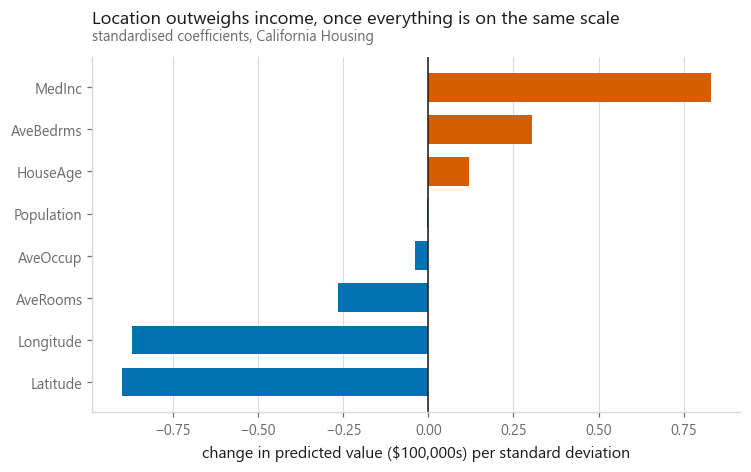

In [7]:
fitted = model.fit(X, y)
weights = pd.Series(fitted.named_steps["linearregression"].coef_,
                    index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(7.6, 4.2))
colours = [style.HIGHLIGHT if w > 0 else style.PALETTE[0] for w in weights]
ax.barh(weights.index, weights.values, color=colours, height=0.68)
ax.axvline(0, color=style.INK, lw=1)
ax.set_xlabel("change in predicted value ($100,000s) per standard deviation")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
style.title(ax,
            "Location outweighs income, once everything is on the same scale",
            "standardised coefficients, California Housing")
style.save(fig, FIG / "fig-02-coefficients.png")

print(weights.round(3).to_string())

I expected income to have the largest weight here, and it does not. **Latitude
at -0.90 and longitude at -0.87 both outrank income at 0.83**, and both are
negative: the model has decided that value falls as you go north, and falls as
you go east. Whether latitude or longitude comes out nominally larger is not worth
a sentence, since the two sit within a few hundredths of each other on weights
near one. The finding is that the pair of them outrank the column everybody
expects to lead. [01-01](../../01-foundations/01-what-machine-learning-does/) gets
the same three numbers on an 80% split of the same data.

Read that as a fact about the model rather than a fact about geography. Two
straight lines are the model's only way of saying "the south-west coast is
expensive and the inland is not". Price falls off with distance from the coast,
the California coast runs diagonally, and a plane can approximate a diagonal
boundary only by leaning hard on both coordinates at once. So the model spends its
two largest weights drawing a map, badly. That is a preview of why a tree does
better here: a tree splits on latitude, then on longitude, and gets the same
boundary for free rather than paying for it in coefficients.

Income at 0.83 is the largest *positive* weight, and it is still the single most
useful column, which is what the one-feature plot showed. Size of coefficient
and usefulness of feature are related but not the same thing.

A warning that applies to every linear model you will ever fit: **these weights
are not causes.** `AveBedrms` having a positive weight does not mean adding a
bedroom raises a district's median value. It means that, holding the other seven
features fixed, districts with more bedrooms per house tend to be worth more.
Correlation, arranged neatly.

### Looking at the errors

The single most useful diagnostic for a regression model is a plot of what it
predicted against what was true.

districts stuck at the $500k cap : 992 (4.8%)
average error on capped districts: -1.110
average error everywhere else    : +0.056

average error by tenth of true value (capped districts excluded):
  cheapest tenth : +0.325
  middle         : +0.287
  dearest tenth  : -0.964

the average error crosses zero near a true value of 2.50


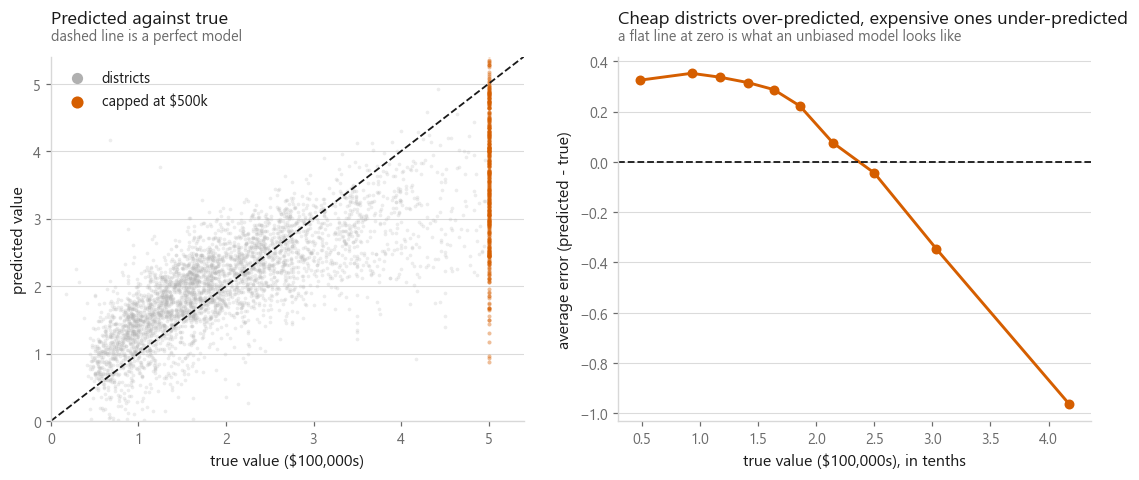

In [8]:
from sklearn.model_selection import cross_val_predict

predicted = cross_val_predict(model, X, y, cv=folds)

residuals = predicted - y.values
capped = y.values >= 4.999

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.3))

# Left: predicted against true, with the capped districts picked out, because
# they are a property of the data rather than a failure of the model.
ordinary = sample[~capped[sample]]
axes[0].scatter(y.values[ordinary], predicted[ordinary], s=6, alpha=0.22,
                c=style.NEUTRAL, linewidths=0, label="districts")
cap_shown = np.random.default_rng(SEED).choice(np.flatnonzero(capped), 500, replace=False)
axes[0].scatter(y.values[cap_shown], predicted[cap_shown], s=7, alpha=0.40,
                c=style.HIGHLIGHT, linewidths=0, label="capped at $500k")
limits = [0, 5.4]
axes[0].plot(limits, limits, color=style.INK, lw=1.2, ls="--")
axes[0].set_xlim(limits)
axes[0].set_ylim(limits)
axes[0].set_xlabel("true value ($100,000s)")
axes[0].set_ylabel("predicted value")
legend = axes[0].legend(loc="upper left", markerscale=3)
for handle in legend.legend_handles:
    handle.set_alpha(1)
style.title(axes[0], "Predicted against true", "dashed line is a perfect model")

# Right: average error within each tenth of the true-value range, capped
# districts excluded. A scatter of residuals hides this; binning makes it plain.
frame = pd.DataFrame({"true": y.values, "error": residuals})[~capped]
deciles = pd.qcut(frame["true"], 10)
by_decile = frame.groupby(deciles, observed=True)["error"].mean()
centres = [interval.mid for interval in by_decile.index]

axes[1].plot(centres, by_decile.values, marker=style.MARKERS[0], color=style.HIGHLIGHT)
axes[1].axhline(0, color=style.INK, lw=1.2, ls="--")
axes[1].set_xlabel("true value ($100,000s), in tenths")
axes[1].set_ylabel("average error (predicted - true)")
style.title(axes[1], "Cheap districts over-predicted, expensive ones under-predicted",
            "a flat line at zero is what an unbiased model looks like")

style.save(fig, FIG / "fig-03-residuals.png")

print(f"districts stuck at the $500k cap : {capped.sum():,} ({capped.mean():.1%})")
print(f"average error on capped districts: {residuals[capped].mean():+.3f}")
print(f"average error everywhere else    : {residuals[~capped].mean():+.3f}\n")
print("average error by tenth of true value (capped districts excluded):")
print(f"  cheapest tenth : {by_decile.iloc[0]:+.3f}")
print(f"  middle         : {by_decile.iloc[4]:+.3f}")
print(f"  dearest tenth  : {by_decile.iloc[-1]:+.3f}")

# Where the bias changes sign is the more useful number than either end, because it
# is the price above which this model is a systematic under-estimate.
crossing = next((c for c, e in zip(centres, by_decile.to_numpy()) if e < 0), None)
print(f"\nthe average error crosses zero near a true value of {crossing:.2f}")

Two separate problems, one per panel.

The **orange stripe at 5.0** is the price cap, not a modelling failure. Those 992
districts were worth more than $500,000 and the dataset records them all as
exactly $500,000, so their true values no longer exist. The model under-predicts
them by 1.11 on average, or $111,000, and it always will.

The right panel is the real finding, and it needed binning to see. A scatter of
residuals looked like a formless smear; averaging the error within each tenth of
the price range shows a clear shape. The error is large and positive across the
cheaper half of districts, falls steadily, crosses zero at the printed value, and
is large and negative in the dearest tenth. The model systematically over-values
cheap districts and under-values expensive ones, and this is with the capped
districts thrown out, so the cap is not the explanation.

The explanation is that a plane cannot bend. The target is right-skewed and its
relationship with income flattens at the top, so the least-squares fit has to
choose one slope for the whole range. It picks the compromise slope, which is too
steep for the cheap end and too shallow for the dear end, and the decile plot is
that compromise drawn out. Any monotone-but-curved relationship produces this
exact tilted line, which makes the plot a diagnostic rather than a curiosity.

The printed average error over the uncapped rows is close to zero, and looks
unbiased for exactly the wrong reason: a large positive bias at the bottom is
cancelling a large negative one at the top. A single summary number hid it and a
chart did not.

There are two fixes and both are later chapters.
[02-03](../03-polynomial-regression/) lets the line bend, which addresses the
curvature directly. Tree-based models in [Part 4](../../04-ensembles/) drop the
straight-line assumption entirely and pick this structure up without being told.

## 5. When it wins, when it loses

Now the useful part. The same model, unchanged, on a dataset where it does
badly, and the reason why.

In [9]:
X_bike, y_bike = datasets.bike_sharing()

bike_scores = cross_validate(make_pipeline(StandardScaler(), LinearRegression()),
                             X_bike, y_bike, cv=folds, scoring="r2")
bike_baseline = cross_validate(DummyRegressor(strategy="mean"), X_bike, y_bike,
                               cv=folds, scoring="r2")

print(f"California Housing : R squared {r2.mean():.3f}")
print(f"Bike Sharing       : R squared {bike_scores['test_score'].mean():.3f}")
print(f"  (mean baseline is 0.000 by definition)")

California Housing : R squared 0.604
Bike Sharing       : R squared 0.388
  (mean baseline is 0.000 by definition)


Same method, same code, and R squared falls from 0.60 to 0.39. The reason is
visible in one chart.

morning commute peak : 08:00     359 hires
midday dip           : 10:00     174 hires
evening commute peak : 17:00     461 hires
quietest hour        : 04:00       6 hires


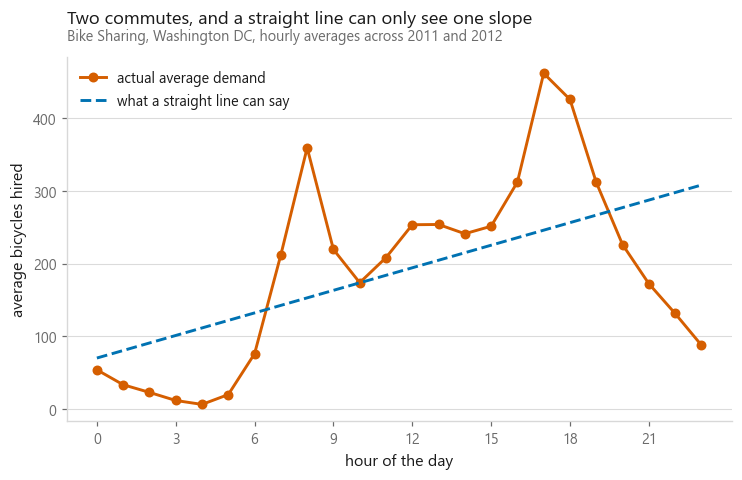

In [10]:
by_hour = pd.DataFrame({"hr": X_bike.hr, "count": y_bike}).groupby("hr")["count"].mean()

fig, ax = plt.subplots(figsize=(7.8, 4.3))
ax.plot(by_hour.index, by_hour.values, marker=style.MARKERS[0],
        color=style.HIGHLIGHT, label="actual average demand")

# What a linear model can express about the hour column: one straight line.
line_slope, line_intercept = np.polyfit(X_bike.hr, y_bike, deg=1)
ax.plot(by_hour.index, line_slope * by_hour.index + line_intercept,
        color=style.PALETTE[0], ls="--", label="what a straight line can say")

ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("hour of the day")
ax.set_ylabel("average bicycles hired")
ax.legend()
style.title(ax,
            "Two commutes, and a straight line can only see one slope",
            "Bike Sharing, Washington DC, hourly averages across 2011 and 2012")
style.save(fig, FIG / "fig-04-where-it-loses.png")

print(f"morning commute peak : 08:00  {by_hour[8]:>6.0f} hires")
print(f"midday dip           : 10:00  {by_hour[10]:>6.0f} hires")
print(f"evening commute peak : 17:00  {by_hour[17]:>6.0f} hires")
print(f"quietest hour        : {by_hour.idxmin():02d}:00  {by_hour.min():>6.0f} hires")

Demand has **two peaks**, at the morning and evening commutes, with a dip
between them. A straight line through the hour column can only say "demand goes
up as the day goes on" or "demand goes down". It cannot say "up, then down, then
up, then down". No amount of fitting fixes this, because the shape is not
available to the model.

There are three ways out, and each is a later chapter:

- **Give the model better features.** Replace `hr` with its sine and cosine, or
  with a one-hot column per hour. This is [01-07](../../01-foundations/07-feature-scaling-and-encoding/).
- **Let the model bend.** Polynomial features in [02-03](../03-polynomial-regression/).
- **Use a model that splits instead of sloping.** Decision trees in
  [03-06](../../03-classification/06-decision-trees/) handle this without being told.

Just to prove the diagnosis, here is the same linear regression with the hour
column one-hot encoded and nothing else changed.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cyclical = ["hr", "weekday", "mnth", "season", "weathersit"]
encoded = ColumnTransformer(
    [("categories", OneHotEncoder(handle_unknown="ignore"), cyclical)],
    remainder=StandardScaler(),
)

improved = cross_validate(make_pipeline(encoded, LinearRegression()),
                          X_bike, y_bike, cv=folds, scoring="r2")

print(f"raw numeric columns  : R squared {bike_scores['test_score'].mean():.3f}")
print(f"hour one-hot encoded : R squared {improved['test_score'].mean():.3f}")

raw numeric columns  : R squared 0.388
hour one-hot encoded : R squared 0.684


R squared goes from 0.39 to 0.68, better than the same model managed on
California Housing. The estimator did not change at all. One-hot encoding gives
the model a separate weight for each hour, so instead of one slope across the
day it can learn twenty-four independent levels, and suddenly "up, down, up,
down" is expressible.

This is worth sitting with, because it is the most reliable lesson in applied
machine learning: **the features are usually where the win is**, not the model.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You want a fast, explainable baseline; relationships look roughly straight; you have more rows than columns |
| **Avoid it when** | The pattern bends or cycles; features are strongly correlated with each other; outliers are common |
| **Assumes** | Errors are independent, have constant variance, and are roughly normal. The prediction stays useful even when these are shaky; the *confidence intervals* do not |
| **Scaling needed** | Not for correctness, yes for interpreting coefficients |
| **Cost to train** | About $O(n \cdot m^2)$ for $m$ features. Instant below a few hundred columns |
| **Main dials** | None. `LinearRegression` has no hyperparameters, which is part of its appeal |
| **Next step** | Add a penalty: [Ridge](../04-ridge-regression/) if features are correlated, [Lasso](../05-lasso-regression/) if you want feature selection |

## What to remember

1. Linear regression finds the weighted sum of your features that minimises
   squared error, and the normal equation solves it exactly in one shot.
2. Solve it with `lstsq`, never by inverting $X^\top X$ yourself.
3. Scale inside a `Pipeline`, so the scaler never sees the test fold.
4. Always compare against predicting the mean. On California Housing the gain
   was 37%; a number with nothing to compare it to means nothing.
5. Read the residual plot. A tilt or a curve in it says the straight-line
   assumption is wrong, which is exactly what happened on Bike Sharing.
6. When a linear model fails on cyclical data, fix the features before you
   reach for a bigger model.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [02-02 Gradient descent, watched step by step](../02-gradient-descent/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#LinearRegression` `#Python` `#ScikitLearn` `#DataScience`
`#MLTutorial` `#NumPy` `#Regression` `#LearnMachineLearning` `#OpenSource`